# Introduction to Information Theory

In [7]:
import numpy as np
import pymc as pm
import xarray as xr
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sb
from typing import Dict, List, Set, Callable


## Example 1.1

A bent coin has probability f of coming up heads. The coin is tossed N times. What is the probability distribution of the number of heads, r? What are the mean and variance of r?

$$ 
\begin{align}
P(r | f, N) &= {N \choose r} f^r (1-f)^{N - r}  \\
&= \frac{N!}{(r!)(N-r)!} f^r (1-f)^{N-r}
\end{align}
$$

$$ E[r] = \frac{1}{N} \Sigma_{r=0}^N P(r | f, N) r $$
$$ V[r] = \frac{1}{N} \Sigma_{r=0}^N P(r | f, N) r^2 - E[r]^2 $$


## Example 1.2

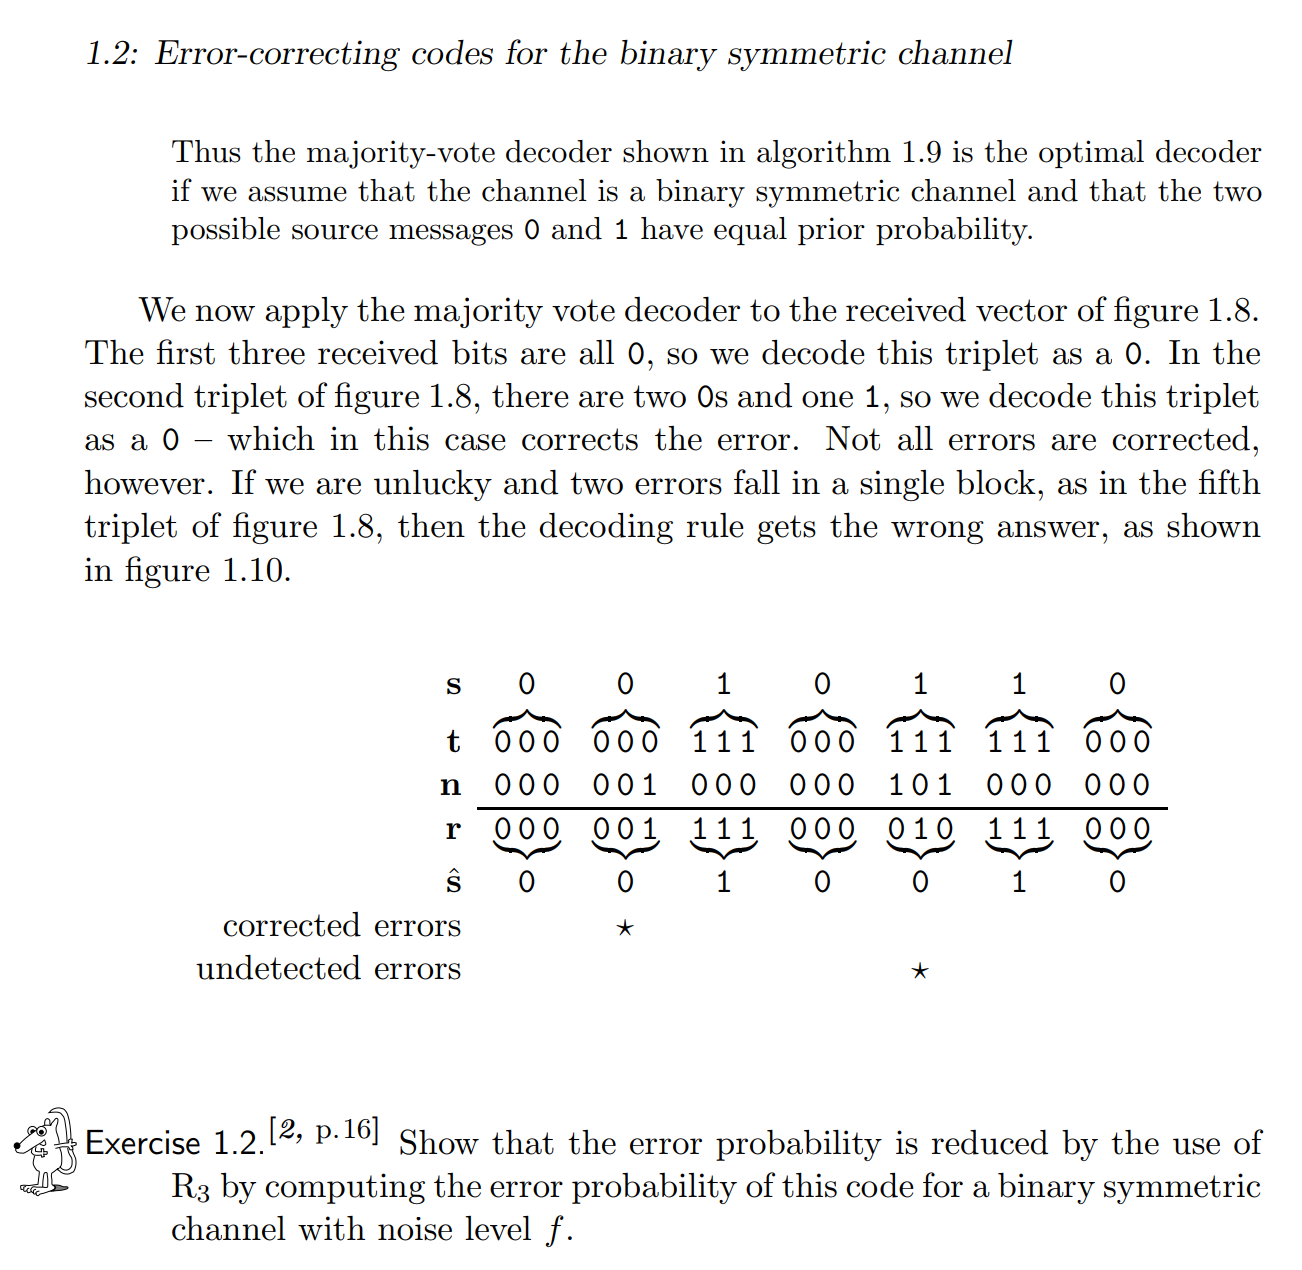

Errors can only occur if two or more digits flip out of 3.

In [14]:
def fact(i: int, agg: int = 1) -> int:
    if i < 0:
        raise ValueError("i must be a nonnegative integer")
    if i <= 1:
        return agg
    else:
        return fact(i - 1, i * agg)

def bin_ll(r: int, n: int, f: float) -> float:
    if r > n:
        raise ValueError("r must be less than n")
    if f < 0:
        raise ValueError("f must be nonnegative")

    seq_counts: Callable[[int, int], int] = lambda r, n: fact(n) / (fact(r) * fact(n-r))
    seq_p: Callable[[int, int, float], float] = lambda r, n, f: (f**r) * ((1-f)**(n-r))
    ll: float = seq_counts(r, n) * seq_p(r, n, f)
    return ll

def bin_over_r(rs: List[int], n: int, f: float) -> float:
    return sum([bin_ll(r, n, f) for r in rs])

print("The original error probability was 0.1 without redundancy")
print(f"The R3 error probability is {bin_over_r([2,3], 3, 0.1)}")

The original error probability was 0.1 without redundancy
The R3 error probability is 0.02800000000000001


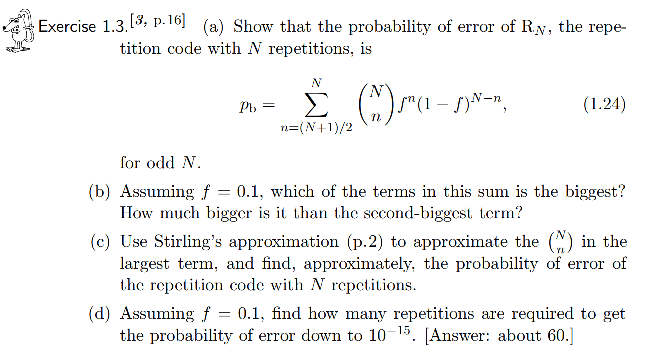

a) Since the trigger for a bit to flip is that the majority of the repeated digts must flip, we can determine by inspection that as long as we count at least a majority of digits flipping, we will achieve a flipped bit.

$$ 2n = 2\frac{N+1}{2} = N + 1 > N $$

b) The biggest term will be the first one because the implied success rate is closest to the actual fraction.

$$
\begin{align}

    {N \choose n} f^n (1-f)^{N-n} - {N \choose (n +1)} f^{n-1} (1-f)^{N - (n + 1)} &= \frac{N!}{n!(N-n)!}f^n (1-f)^{N-n} - \frac{N!}{(n + 1)!(N- n - 1)!} f^{n+1} (1-f)^{N - n - 1} \\
    &=\frac{N!}{n!(N-n-1)!} f^{n} (1-f)^{N - n - 1} [\frac{1}{N-n} (1-f) - \frac{1}{n+1}]

\end{align}
$$

In [27]:
def bin_rn_odd(n: int, f: float) -> Dict[int, float]:
    if n % 2 == 0:
        raise ValueError("Must provide an odd value for n")
    start_r: int = int((n + 1) / 2)
    print(start_r)
    range_r: List[int] = list(range(start_r, n +1))
    return {r: bin_ll(r, n, f) for r in range_r}

bin_rn_odd(59, 0.1)

30


{30: 2.7852069974823716e-15,
 31: 2.8950180260569453e-16,
 32: 2.814600858666475e-17,
 33: 2.558728053333159e-18,
 34: 2.174082659694841e-19,
 35: 1.725462428329239e-20,
 36: 1.2781203172809179e-21,
 37: 8.82785804728562e-23,
 38: 5.678739094745135e-24,
 39: 3.3975362105312777e-25,
 40: 1.887520116961821e-26,
 41: 9.718938271619132e-28,
 42: 4.628065843628158e-29,
 43: 2.0330004997849793e-30,
 44: 8.214143433474664e-32,
 45: 3.0422753457313573e-33,
 46: 1.0287887642569808e-34,
 47: 3.161762159655024e-36,
 48: 8.782672665708398e-38,
 49: 2.1906893270474468e-39,
 50: 4.868198504549881e-41,
 51: 9.545487263823298e-43,
 52: 1.631707224585179e-44,
 53: 2.3945389040034072e-46,
 54: 2.9562208691400093e-48,
 55: 2.9860816860000095e-50,
 56: 2.3699061000000078e-52,
 57: 1.3859100000000046e-54,
 58: 5.310000000000017e-57,
 59: 1.0000000000000033e-59}

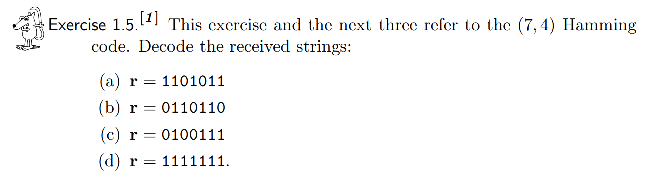

Since we will be using the (7, 4) Hamming code for each of these, we could just create the relevant matrices directly, but where is the fun in that. Let's generate something a bit more general for any Hamming code structure. Here is the general pipeline for message transmission. (*Scratch that, thought I noticed a more general pattern. If I had 2 source bits, I'd need one parity bit. If I had 3 source bits, I'd need 1 parity bits. For 4, I need 3... Should come back to this.*)

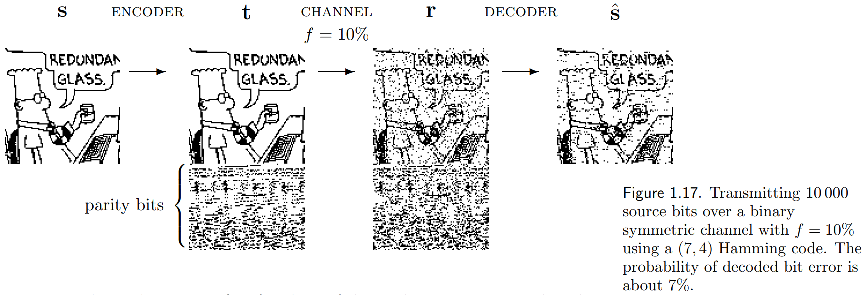

To convert the source data $s$ to the encoded data $t$, we need a generator matrix $G$ that will transmit the original source data $s$ with parity bits appended to complete $t$. In the (7, 4) case, $s$ is a 4x1 vector and $G$ is a 4x7 matrix constructed by concatenating a 4x4 identity matrix and a 4x3 matrix $P$ that computes the partiy bits.

$$ s^T = [s_1,  s_2, s_3, s_4 ] $$
$$ G = [I_4, P] $$
where
$$ 
P= 
\begin{bmatrix}
1, 1, 1, 0 \\
0, 1, 1, 1 \\
1, 0, 1 ,1
\end{bmatrix}
$$

Note how $P$ is constructed. Each row corresponds to a parity bit calculation (modulo 2), and the source bits used in the calculation are (1, 2, 3), (2, 3, 4), and (1, 3, 4). Essentially, we have pivoted around the 3rd bit and chosen every combination of three digits available: ${n - 1 \choose k - 1}$. This feels suggestive of a general rule, but I will not pursue that here. Let's construct $G$.

In [43]:
I: np.ndarray = np.eye(N=4)
P: np.ndarray = np.array([
    [1,1,1,0],
    [0,1,1,1],
    [1,0,1,1]
]).T
G: np.ndarray = np.concatenate([I, P], axis=1)
G

array([[1., 0., 0., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1., 1., 0.],
       [0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 1., 1.]])

Suppose our source $s$ was $[1,0,1,0]$, we can compute $t$ as follows:

In [ ]:
s_test: np.ndarray = np.array([1,0,1,0])
t_test: np.ndarray = np.dot(G.T, s_test) % 2 # Note how for bit parity, we want modulo 2
t_test

array([1., 0., 1., 0., 0., 1., 0.])

The parity check matrix is just the transposed matrix $P^T$ (now 3x4) concatenated with an identity matrix that is now just 3x3 to evaluate the parity bits.

In [52]:
H: np.ndarray = np.concatenate([P.T, np.eye(N=3)], axis=1)
H

array([[1., 1., 1., 0., 1., 0., 0.],
       [0., 1., 1., 1., 0., 1., 0.],
       [1., 0., 1., 1., 0., 0., 1.]])

The parity check effectively adds the values in the source vector to the parity bits. If none of the bits have been flipped, then we should get a zero vector back (again, modulo 2).

In [55]:
np.dot(H, t_test) % 2

array([0., 0., 0.])

The parity check matrix effectively just undoes what the generator matrix did.

In [57]:
np.dot(H, G.T) % 2

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Of course, we are dealing with a noise channel. So, if we do encounter some noise, we will not get a zero vector. Let's flip the second source digit to see what happens.

In [63]:
noise: np.ndarray = np.array([0,1,0,0,0,0,0]) # Note how any of the bits, source or parity, can be flipped
r: np.ndarray = (np.dot(G.T, s_test) + noise) % 2
print("r: ", r)
z: np.ndarray = np.dot(H, r) % 2
print("z = H*r", z)

r:  [1. 1. 1. 0. 0. 1. 0.]
z = H*r [1. 1. 0.]


Two of our parity bits have flipped!